# Joint MAP vs Mode-selection MRF, with Langevin as a search ablation

## Setup

In [1]:
from pathlib import Path
import csv
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "sampler_research" / "src"))

from sampler_research.io import load_sampler_arrays
from sampler_research import method4_mrf as rm4
from sampler_research.graph import grid_edges_8

DATASET = "phase_1_homoscedastic"
DATA_DIR = PROJECT_ROOT / "outputs" / "data"
RUNS_DIR = PROJECT_ROOT / "outputs" / "runs"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EDGES = grid_edges_8(8, 8)

# Toy GMM parameters (the decoder emits only pi, mu, sigma, coords).
d = load_sampler_arrays(DATA_DIR / f"{DATASET}.npz")
pi, mu, sigma = d["pi"], d["mu"], d["sigma"]


def read_scores(path):
    """Read a persisted *_scores.csv into list-of-dict rows (float where possible)."""
    rows = []
    with open(path, newline="") as fh:
        for raw in csv.DictReader(fh):
            row = {}
            for k, v in raw.items():
                try:
                    row[k] = float(v)
                except (TypeError, ValueError):
                    row[k] = v
            rows.append(row)
    return rows


# Arrays from .npz (fields + Mode-selection MRF modes); metric tables from .csv.
A = np.load(RUNS_DIR / "stage_a_baselines" / f"{DATASET}_baselines.npz")
B = np.load(RUNS_DIR / "stage_b_regularised_map" / f"{DATASET}_regularised_map.npz")
C = np.load(RUNS_DIR / "stage_c_method4_mrf" / f"{DATASET}_method4_mrf.npz")

scores_a = {r["baseline"]: r for r in read_scores(RUNS_DIR / "stage_a_baselines" / "stage_a_scores.csv")}
scores_b = read_scores(RUNS_DIR / "stage_b_regularised_map" / "stage_b_scores.csv")
scores_c = read_scores(RUNS_DIR / "stage_c_method4_mrf" / "stage_c_scores.csv")
scores_d = read_scores(RUNS_DIR / "stage_d_method5_langevin" / "stage_d_scores.csv")

# Mode-selection MRF's extracted modes are the shared reference for the smearing diagnostic.
MODE_VALUES, VALID_MASK = C["mode_values"], C["valid_mask"]

# Four focused baseline anchors carried through every figure.
ANCHORS = ["iid", "mode_map", "smoothed_map", "a_star"]
anchor_fields = {name: A[name] for name in ANCHORS}

print(f"dataset: {DATASET}   grid: {pi.shape[0]}x{pi.shape[1]}   K={pi.shape[-1]} components")
print(f"loaded   Joint MAP: {len(B['lambdas'])} λ   Mode-selection MRF: {len(C['betas'])} β   "
      f"Langevin: {len(scores_d)} λ   anchors: {len(ANCHORS)}")

dataset: phase_1_homoscedastic   grid: 8x8   K=4 components
loaded   Joint MAP: 7 λ   Mode-selection MRF: 5 β   Langevin: 7 λ   anchors: 4


## 1. Baseline anchors

In [2]:
# Baseline anchor metrics (straight from the persisted run).
print(f"{'anchor':>14s} {'NLL/N':>8s} {'R̃':>8s} {'HF':>8s} {'slope':>8s} {'mono':>6s}")
for name in ANCHORS:
    s = scores_a[name]
    print(f"{name:>14s} {s['nll_over_n']:8.3f} {s['r_tilde']:8.3f} "
          f"{s['spectral_hf_ratio']:8.3f} {s['spectral_slope']:8.3f} "
          f"{s['spectral_monotone_fraction']:6.3f}")

        anchor    NLL/N       R̃       HF    slope   mono
           iid    1.977    2.077    0.762    0.157  0.667
      mode_map    1.551    1.462    0.479   -0.678  0.333
  smoothed_map    1.730    0.184    0.097   -4.529  1.000
        a_star    1.591    0.495    0.174   -2.037  1.000


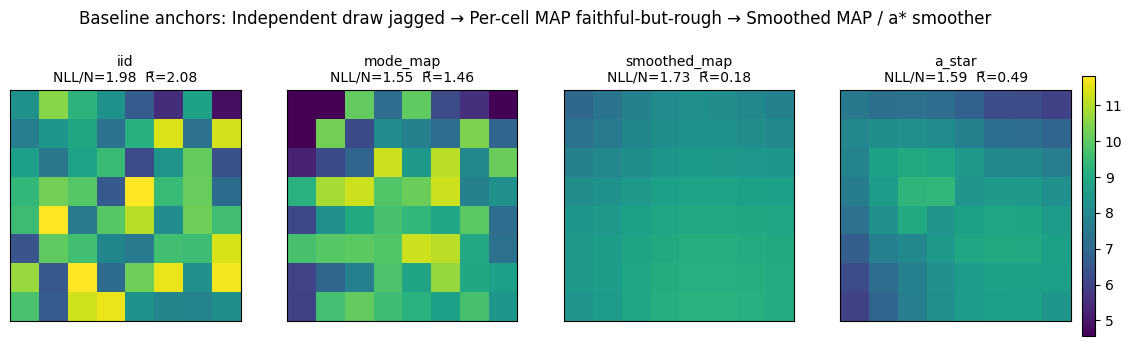

In [3]:
# Optional field-map row: makes "jagged -> faithful-but-rough -> smoother" concrete.
stacked = np.concatenate([f.reshape(-1) for f in anchor_fields.values()])
vmin, vmax = np.percentile(stacked, [1, 99])
fig, axes = plt.subplots(1, len(ANCHORS), figsize=(3.5 * len(ANCHORS), 3.6))
for ax, name in zip(axes, ANCHORS):
    im = ax.imshow(anchor_fields[name], origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
    s = scores_a[name]
    ax.set_title(f"{name}\nNLL/N={s['nll_over_n']:.2f}  R̃={s['r_tilde']:.2f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.012, pad=0.01)
fig.suptitle("Baseline anchors: Independent draw jagged → Per-cell MAP faithful-but-rough → Smoothed MAP / a* smoother", y=1.04)
plt.show()

## 2. Joint MAP — λ-sweep

In [4]:
# Joint MAP λ-sweep table (persisted run).
print(f"{'λ':>6s} {'NLL/N':>8s} {'R̃':>8s} {'HF':>8s} {'slope':>8s} {'mono':>6s} {'restart ΔJ':>12s}")
for r in scores_b:
    print(f"{r['lambda']:6g} {r['nll_over_n']:8.3f} {r['r_tilde']:8.3f} "
          f"{r['spectral_hf_ratio']:8.3f} {r['spectral_slope']:8.3f} "
          f"{r['spectral_monotone_fraction']:6.3f} {r['restart_spread']:12.2e}")

     λ    NLL/N       R̃       HF    slope   mono   restart ΔJ
     0    1.479    1.369    0.494   -0.590  0.333     1.07e-02
  0.05    1.505    0.985    0.320   -1.046  0.667     2.45e-03
   0.1    1.508    0.783    0.269   -1.299  0.667     5.96e-02
   0.2    1.510    0.252    0.089   -2.912  1.000     5.70e-02
   0.5    1.544    0.307    0.165   -2.013  1.000     9.92e-02
     1    1.562    0.266    0.172   -2.022  1.000     6.63e-02
     2    1.581    0.238    0.179   -2.016  1.000     1.01e-06


## 3. Mode-selection MRF — β-sweep

In [5]:
# Mode-selection MRF β-sweep table (persisted run). frac columns are the v1 drift thresholds.
mc = C["mode_counts"]
print(f"modes/cell: min={int(mc.min())} mean={mc.mean():.2f} max={int(mc.max())}   "
      f"(K={pi.shape[-1]} components collapse to 1-2 modes at σ=1)\n")
print(f"{'β':>6s} {'NLL/N':>8s} {'R̃':>8s} {'HF':>7s} {'ΔNLL→mode':>10s} "
      f"{'>0.5σ':>7s} {'>1σ':>6s} {'restart ΔJ':>12s}")
for r in scores_c:
    print(f"{r['beta']:6g} {r['nll_over_n']:8.3f} {r['r_tilde']:8.3f} "
          f"{r['spectral_hf_ratio']:7.3f} {r['dnll_to_mode_mean']:10.4f} "
          f"{r['dnll_frac_gt_0p125_v1']:7.3f} {r['dnll_frac_gt_0p5_v1']:6.3f} "
          f"{r['restart_spread']:12.2e}")

modes/cell: min=1 mean=1.52 max=2   (K=4 components collapse to 1-2 modes at σ=1)

     β    NLL/N       R̃      HF  ΔNLL→mode   >0.5σ    >1σ   restart ΔJ
     0    1.455    1.733   0.568     0.0000   0.000  0.000     0.00e+00
 0.025    1.457    1.015   0.290     0.0018   0.000  0.000     1.20e-03
  0.05    1.467    0.820   0.220     0.0119   0.031  0.000     2.02e-02
 0.075    1.479    0.604   0.137     0.0240   0.062  0.016     3.39e-02
   0.1    1.508    0.943   0.283     0.0530   0.125  0.047     5.83e-02


## 4. The Pareto plane

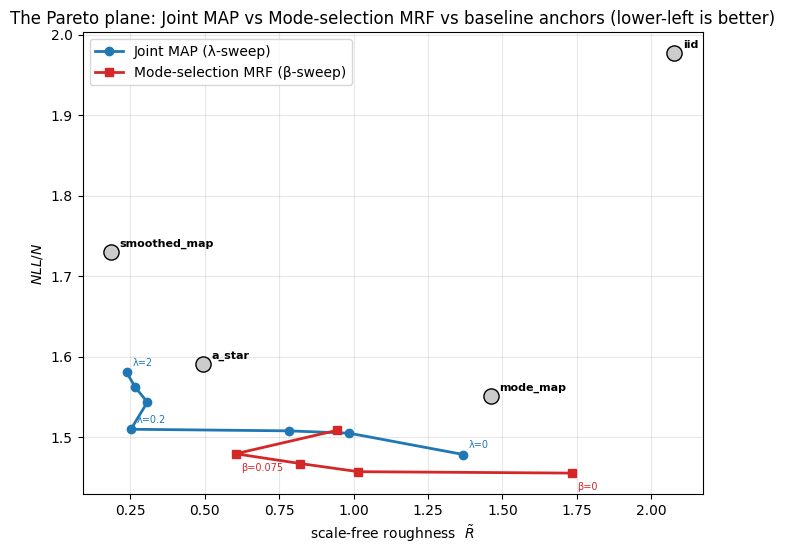

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

# Joint MAP (continuous λ-sweep).
ax.plot(B["r_tilde"], B["nll_over_n"], "o-", color="C0", lw=2, label="Joint MAP (λ-sweep)")
for lam, r, n in zip(B["lambdas"], B["r_tilde"], B["nll_over_n"]):
    if lam in (0.0, 0.2, 2.0):
        ax.annotate(f"λ={lam:g}", (r, n), fontsize=7, color="C0",
                    xytext=(4, 5), textcoords="offset points")

# Mode-selection MRF (discrete β-sweep).
ax.plot(C["r_tilde"], C["nll_over_n"], "s-", color="C3", lw=2, label="Mode-selection MRF (β-sweep)")
for beta, r, n in zip(C["betas"], C["r_tilde"], C["nll_over_n"]):
    if beta in (0.0, 0.075, 0.2):
        ax.annotate(f"β={beta:g}", (r, n), fontsize=7, color="C3",
                    xytext=(4, -12), textcoords="offset points")

# Baseline anchors.
for name in ANCHORS:
    s = scores_a[name]
    ax.scatter(s["r_tilde"], s["nll_over_n"], s=120, edgecolor="k", color="0.8", zorder=3)
    ax.annotate(name, (s["r_tilde"], s["nll_over_n"]), fontsize=8, fontweight="bold",
                xytext=(6, 4), textcoords="offset points")

ax.set_xlabel(r"scale-free roughness  $\tilde{R}$")
ax.set_ylabel(r"$NLL/N$")
ax.set_title("The Pareto plane: Joint MAP vs Mode-selection MRF vs baseline anchors (lower-left is better)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 5. The non-smearing diagnostic

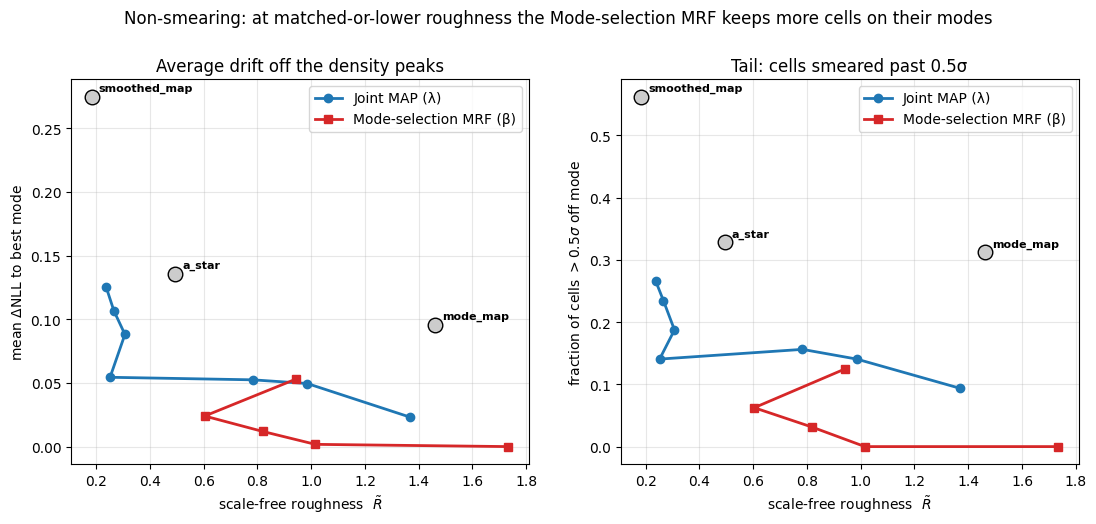

In [7]:
def smear_mean_frac(field):
    """(mean ΔNLL→mode, fraction of cells >0.5σ off mode) vs the Mode-selection MRF's shared modes."""
    delta = rm4.delta_nll_to_best_mode(field, pi, mu, sigma, MODE_VALUES, VALID_MASK)
    return delta["mean"], delta["frac_over"][0]

# Cheap live diagnostic on the loaded fields (no sweep rerun).
b_mean, b_frac = zip(*(smear_mean_frac(f) for f in B["fields"]))
c_mean, c_frac = zip(*(smear_mean_frac(f) for f in C["fields"]))
anchor_smear = {name: smear_mean_frac(anchor_fields[name]) for name in ANCHORS}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
panels = [
    (axes[0], b_mean, c_mean, 0, r"mean $\Delta$NLL to best mode", "Average drift off the density peaks"),
    (axes[1], b_frac, c_frac, 1, r"fraction of cells $>0.5\sigma$ off mode", "Tail: cells smeared past 0.5σ"),
]
for ax, b_y, c_y, idx, ylab, title in panels:
    ax.plot(B["r_tilde"], b_y, "o-", color="C0", lw=2, label="Joint MAP (λ)")
    ax.plot(C["r_tilde"], c_y, "s-", color="C3", lw=2, label="Mode-selection MRF (β)")
    for name in ("mode_map", "a_star", "smoothed_map"):
        y = anchor_smear[name][idx]
        ax.scatter(scores_a[name]["r_tilde"], y, s=110, edgecolor="k", color="0.8", zorder=3)
        ax.annotate(name, (scores_a[name]["r_tilde"], y), fontsize=8, fontweight="bold",
                    xytext=(5, 4), textcoords="offset points")
    ax.set_xlabel(r"scale-free roughness  $\tilde{R}$")
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.suptitle("Non-smearing: at matched-or-lower roughness the Mode-selection MRF keeps more cells on their modes", y=1.02)
plt.show()

## 6. Langevin — stochastic-search ablation

     λ JointMAP NLL Langevin NLL  JointMAP R̃  Langevin R̃        ΔJ    floor material?
     0        1.479        1.482        1.369        1.399    0.0037   0.0107     False
  0.05        1.505        1.496        0.985        0.971   -0.0281   0.0025      True
   0.1        1.508        1.498        0.783        0.648   -0.0244   0.0596     False
   0.2        1.510        1.510        0.252        0.252   -0.0000   0.0570     False
   0.5        1.544        1.544        0.307        0.307   -0.0000   0.0992     False
     1        1.562        1.562        0.266        0.266    0.0000   0.0663     False
     2        1.581        1.581        0.238        0.238    0.0000   0.0000     False


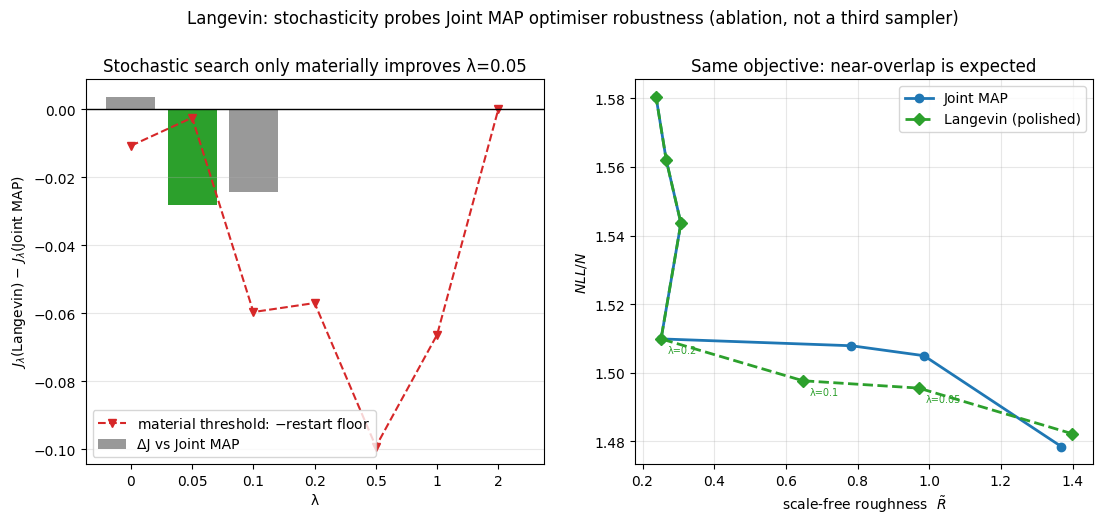

In [8]:
# Langevin vs Joint MAP at matched λ (persisted run).
b_by_lam = {round(float(l), 4): (float(n), float(r))
            for l, n, r in zip(B["lambdas"], B["nll_over_n"], B["r_tilde"])}

print(f"{'λ':>6s} {'JointMAP NLL':>12s} {'Langevin NLL':>12s} {'JointMAP R̃':>12s} {'Langevin R̃':>12s} "
      f"{'ΔJ':>9s} {'floor':>8s} {'material?':>9s}")
for row in scores_d:
    m1n, m1r = b_by_lam[round(row["lambda"], 4)]
    material = str(row["material_improvement"]).lower() == "true"
    print(f"{row['lambda']:6g} {m1n:12.3f} {row['nll_over_n']:12.3f} {m1r:12.3f} {row['r_tilde']:12.3f} "
          f"{row['delta_j_vs_method1']:9.4f} {row['restart_floor']:8.4f} {str(material):>9s}")

x = np.arange(len(scores_d))
labels = [f"{row['lambda']:g}" for row in scores_d]
delta_j = np.array([row["delta_j_vs_method1"] for row in scores_d])
floor = np.array([row["restart_floor"] for row in scores_d])
material = np.array([str(row["material_improvement"]).lower() == "true" for row in scores_d])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(x, delta_j, color=np.where(material, "C2", "0.6"), label="ΔJ vs Joint MAP")
axes[0].plot(x, -floor, "v--", color="C3", label=r"material threshold: $-$restart floor")
axes[0].axhline(0.0, color="k", lw=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel("λ")
axes[0].set_ylabel(r"$J_\lambda$(Langevin) $-$ $J_\lambda$(Joint MAP)")
axes[0].set_title("Stochastic search only materially improves λ=0.05")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend()

axes[1].plot(B["r_tilde"], B["nll_over_n"], "o-", color="C0", lw=2, label="Joint MAP")
axes[1].plot([row["r_tilde"] for row in scores_d], [row["nll_over_n"] for row in scores_d],
             "D--", color="C2", lw=2, label="Langevin (polished)")
for row in scores_d:
    if row["lambda"] in (0.05, 0.1, 0.2):
        axes[1].annotate(f"λ={row['lambda']:g}", (row["r_tilde"], row["nll_over_n"]),
                         fontsize=7, color="C2", xytext=(5, -10), textcoords="offset points")
axes[1].set_xlabel(r"scale-free roughness  $\tilde{R}$")
axes[1].set_ylabel(r"$NLL/N$")
axes[1].set_title("Same objective: near-overlap is expected")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle("Langevin: stochasticity probes Joint MAP optimiser robustness (ablation, not a third sampler)", y=1.02)
plt.show()

## Appendix — gradient correctness

In [9]:
from sampler_research import regularised_map as rm
from sampler_research.graph import graph_laplacian

lap = graph_laplacian(8, 8)
n_edges = len(EDGES)
x = anchor_fields["mode_map"] + np.random.default_rng(0).normal(scale=0.5, size=mu.shape[:2])
lam = 0.5

analytic = rm.objective_gradient(x, pi, mu, sigma, lam, laplacian=lap, n_edges=n_edges)
eps, numeric = 1e-6, np.zeros_like(x)
flat = x.reshape(-1)
for i in range(flat.size):
    xp, xm = flat.copy(), flat.copy(); xp[i] += eps; xm[i] -= eps
    jp = rm.objective(xp.reshape(x.shape), pi, mu, sigma, lam, laplacian=lap, n_edges=n_edges)
    jm = rm.objective(xm.reshape(x.shape), pi, mu, sigma, lam, laplacian=lap, n_edges=n_edges)
    numeric.reshape(-1)[i] = (jp - jm) / (2 * eps)

err = np.abs(analytic - numeric).max()
print(f"max |analytic - finite-difference| gradient error = {err:.2e}")
print("confirms the closed-form gradient in regularised_map.py that Joint MAP / Langevin descend")

max |analytic - finite-difference| gradient error = 9.36e-10
confirms the closed-form gradient in regularised_map.py that Joint MAP / Langevin descend
